In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob
import os

print("PyTorch Version:", torch.__version__)
print("Environment Ready!")

PyTorch Version: 2.4.1
Environment Ready!


In [6]:
# Path to baseline checkpoint matrix
baseline_path = 'results/baseline_r2_matrix.npz'

baseline_data = np.load(baseline_path)
baseline_matrix = baseline_data['values'][-1]  # Final epoch
baseline_r2 = np.diag(baseline_matrix).mean()

print(f"--- 1st-Order Baseline Model ---")
print(f"Path: {baseline_path}")
print(f"Average Diagonal R^2 Score: {baseline_r2:.4f}")

--- 1st-Order Baseline Model ---
Path: results/baseline_r2_matrix.npz
Average Diagonal R^2 Score: 0.9678


In [5]:
# Path to 2nd-order checkpoint matrix
# order2_path = 'BISCUITNF_2ndOrder/BISCUITNF_32l_7b_64hid_causalworld/version_3/r2_matrix_grouped_latents_test.npz'
order2_path = 'results/2nd_order_r2_matrix.npz'


order2_data = np.load(order2_path)
order2_matrix = order2_data['values'][-1]  # Final epoch
order2_r2 = np.diag(order2_matrix).mean()

print(f"--- 2nd-Order Temporal Model (t-2, t-1 -> t) ---")
print(f"Path: {order2_path}")
print(f"Average Diagonal R^2 Score: {order2_r2:.4f}")

--- 2nd-Order Temporal Model (t-2, t-1 -> t) ---
Path: results/2nd_order_r2_matrix.npz
Average Diagonal R^2 Score: 0.9652


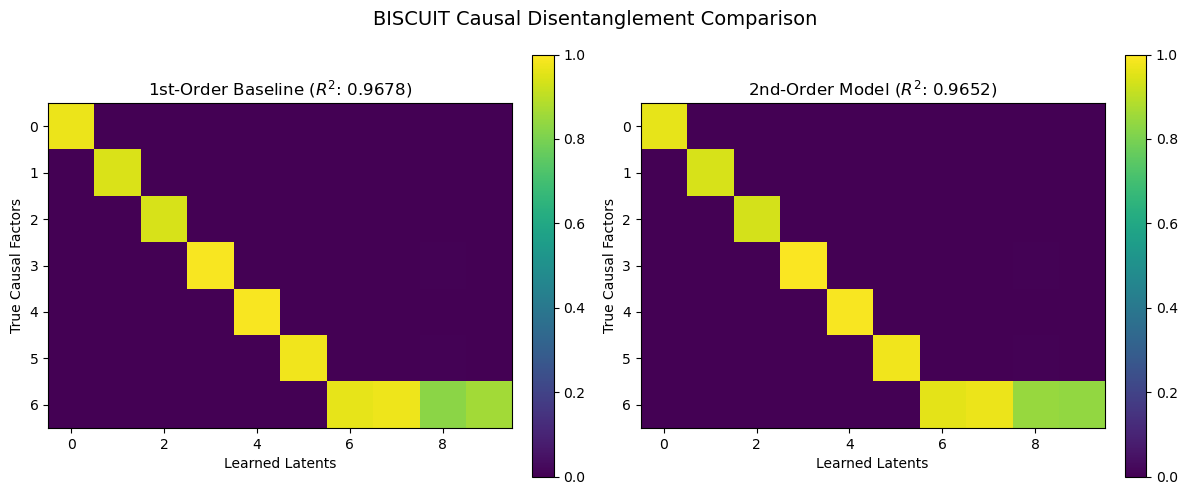

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Baseline
im0 = axes[0].imshow(baseline_matrix, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title(f"1st-Order Baseline ($R^2$: {baseline_r2:.4f})")
axes[0].set_xlabel("Learned Latents")
axes[0].set_ylabel("True Causal Factors")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2nd-Order
im1 = axes[1].imshow(order2_matrix, vmin=0, vmax=1, cmap='viridis')
axes[1].set_title(f"2nd-Order Model ($R^2$: {order2_r2:.4f})")
axes[1].set_xlabel("Learned Latents")
axes[1].set_ylabel("True Causal Factors")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("BISCUIT Causal Disentanglement Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### Data Preparation & The Autoencoder

The experiments were run using the **CausalWorld** dataset, which consists of image sequences of a robotic hand interacting with blocks. 

However, training a Normalizing Flow directly on raw, high-dimensional pixel data is extremely computationally expensive. To solve this, BISCUIT uses a **two-stage architecture**:

1. **Stage 1 (Dimensionality Reduction):** A pre-trained Autoencoder compresses the raw images into a compact, 32-dimensional latent representation. 
2. **Stage 2 (Causal Discovery):** The Normalizing Flow (which we modify for 2nd-order dependencies) takes those 32 latents as input and learns to disentangle them into the true causal variables.

Before launching our experiments on the cluster, we first had to download the CausalWorld dataset and the pre-trained Autoencoder weights (`AE_32l_128hid.ckpt`).

Because the Autoencoder is fully pre-trained, we freeze its weights during our experiment. We simply pass the path of the `.ckpt` file into our training script using the `--autoencoder_checkpoint` argument. 

During training, the PyTorch Lightning module automatically loads this checkpoint, encodes the batches of raw images into the 32-dimensional latent space, and feeds that continuous sequence into our custom `BISCUITNF_2ndOrder` normalizing flow.

### The Theory: Moving Beyond the Markov Assumption

The standard BISCUIT architecture relies on a strict first-order **Markov assumption**. It assumes that the next state of the world ($z_t$) can be entirely predicted using only the immediate previous state ($z_{t-1}$) and the current action/intervention ($a_t$).

Mathematically, the baseline model learns this distribution:
$$ P(z_t | z_{t-1}, a_t) $$

However, in many real-world physical systems, a single previous frame doesn't capture the full dynamics (like velocity or acceleration). Our goal was to test if BISCUIT's causal identifiability proofs hold up if we force the model to learn **second-order temporal dependencies**, meaning the model must look at two historical time steps to predict the future:
$$ P(z_t | z_{t-1}, z_{t-2}, a_t) $$

By comparing the $R^2$ scores of the 1st-order and 2nd-order models, we can empirically verify if entangling the causal variables with a deeper history degrades the model's ability to disentangle the true causal factors.


### The Architectural Modifications

To implement this without modifying the original codebase, we created a new Python class (`BISCUITNF_2ndOrder`) that inherited from the baseline model. We had to modify three core components:

1. **The Data Pipeline:** Changed the dataloader to extract sequences of 3 frames (`--seq_len 3`) instead of the default 2.
2. **Latent Concatenation:** Sliced the model's latent representations into $z_{t-2}$, $z_{t-1}$, and $z_t$, and concatenated the historical states along the feature dimension to create a single doubled-context vector.
3. **Transition Prior:** The neural networks inside the transition prior were designed for 1st-order dimensions. We had to overwrite the `MultivarLinear` and `MultivarSequential` layers to accept exactly twice the number of input features (from 32 to 64).